# EDA on IPL 2022 data

This project performs an Exploratory Data Analysis (EDA) on IPL 2022 data using Pandas, NumPy, Matplotlib, and Seaborn. Since the dataset has zero null values, the code focuses on grouping and sorting to answer strategic questions about toss advantages, stadium behaviors, team dominance, and chronological scoring trends.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Data Loading and Initial Inspection
loading the raw `IPL.csv` file into a Pandas DataFrame and will be looking at its baseline shape.
1. The dataset contains 74 match rows and 20 columns.
2. using `.describe()` and `.info()` to understand the score averages and data types.

In [3]:
df = pd.read_csv("IPL.csv")

In [5]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [8]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [13]:
print(f"rows in data are : {df.shape[0]} and columns are : {df.shape[1]}")

rows in data are : 74 and columns are : 20


In [21]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [30]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

# which team won the most matches

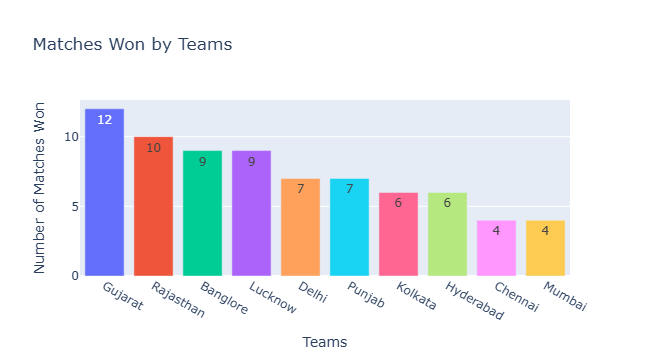

In [13]:
match_wins = df['match_winner'].value_counts()
fig = px.bar( x=match_wins.index, y=match_wins.values, color=match_wins.index,
     color_continuous_scale='Turbo', text=match_wins.values, title='Matches Won by Teams')

fig.update_layout( xaxis_title='Teams', yaxis_title='Number of Matches Won',showlegend=False)
fig.show()

In [33]:
# to see the toss trends: which is opted most? field or batting?
df['toss_decision'].unique() 

array(['Field', 'Bat'], dtype=object)

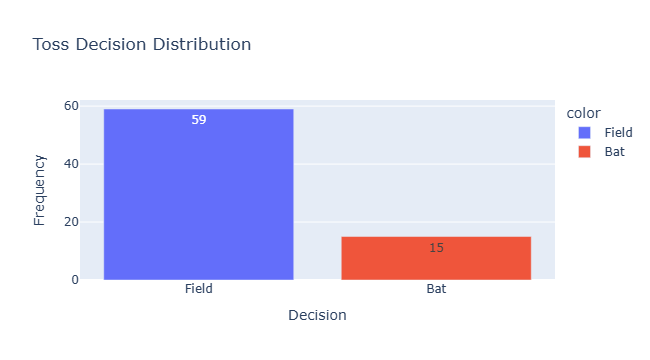

In [51]:
#meaning category data so, we wanna see trends
toss = df['toss_decision'].value_counts()
fig = px.bar(x=toss.index,y=toss.values,text=toss.values,
    title='Toss Decision Distribution', color=toss.index )
fig.update_layout(
    xaxis_title='Decision',yaxis_title='Frequency') 
fig.show()

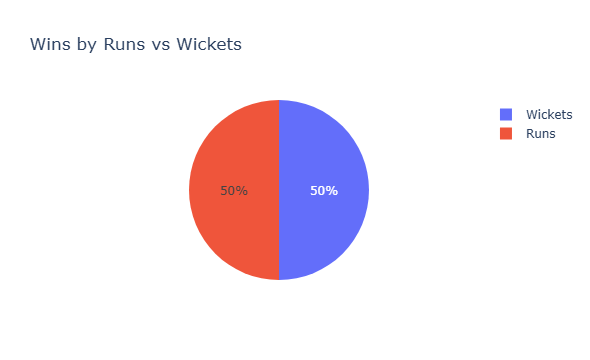

In [11]:
# win by runs or wickets
win_type = df['won_by'].value_counts()
fig = px.pie(
    values=win_type.values, names=win_type.index, title='Wins by Runs vs Wickets' )
fig.show()

# KEY PLAYER ANALYSIS

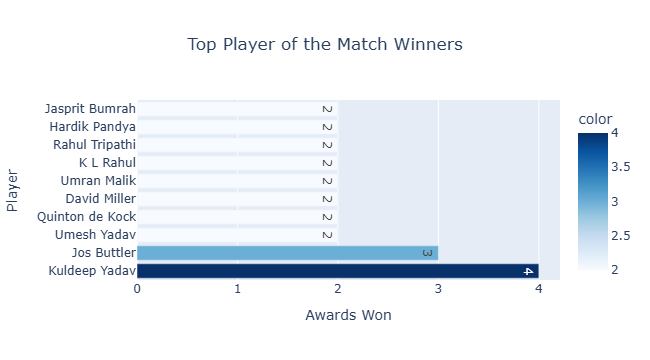

In [4]:
#who won the most 'PLAYER of the match'
pom = df['player_of_the_match'].value_counts().head(10)
fig = px.bar( x=pom.values,y=pom.index,orientation='h', title='Top Player of the Match Winners' , 
              text=pom.values, color=pom.values, color_continuous_scale='Blues')
fig.update_layout( xaxis_title='Awards Won', yaxis_title='Player', title_x=0.5)
fig.show()

In [6]:
#top 10 scorers
df = pd.read_csv("IPL.csv")
d2 = df['top_scorer'].value_counts().head(2)
d2

top_scorer
Jos Buttler        7
Quinton de Kock    5
Name: count, dtype: int64

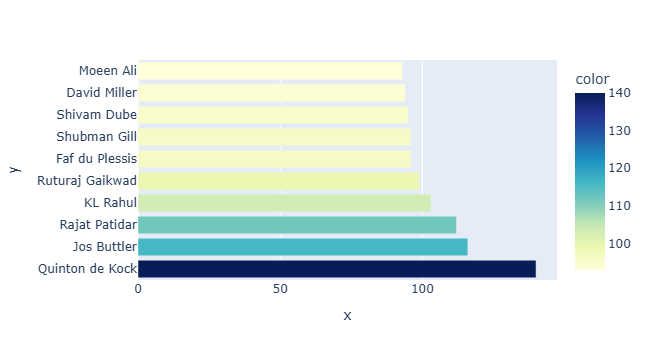

In [5]:
top_scorers = (
    df.groupby('top_scorer')['highscore'].max().sort_values(ascending=False).head(10))
fig = px.bar(
    x=top_scorers.values,
    y=top_scorers.index,
    orientation='h',
    color=top_scorers.values,
    color_continuous_scale='YlGnBu'
)
fig.show()

In [30]:
#top ten best bowling figure
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().head(10).sort_values(ascending=False)
top_bowlers

best_bowling
Jasprit Bumrah     11
Avesh Khan         10
Andre Russell       7
Daniel Sams         7
Dwayne Bravo        6
Harshal Patel       6
Hardik Pandya       4
Harpreet Brar       3
Axar Patel          2
Chetan Sakariya     2
Name: highest_wickets, dtype: int64

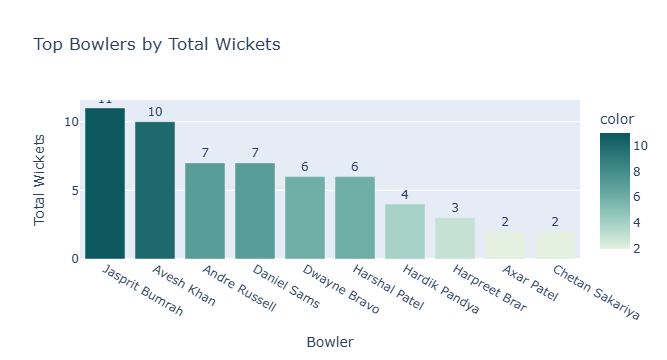

In [33]:
fig = px.bar( x=top_bowlers.index, y=top_bowlers.values, text=top_bowlers.values,
    title='Top Bowlers by Total Wickets', color=top_bowlers.values,
    color_continuous_scale='Mint')
fig.update_layout(
    xaxis_title='Bowler',
    yaxis_title='Total Wickets'
)
fig.update_traces(textposition='outside')
fig.show()

In [7]:
# top venues for the matches
d3 = df['venue'].value_counts()
d3

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

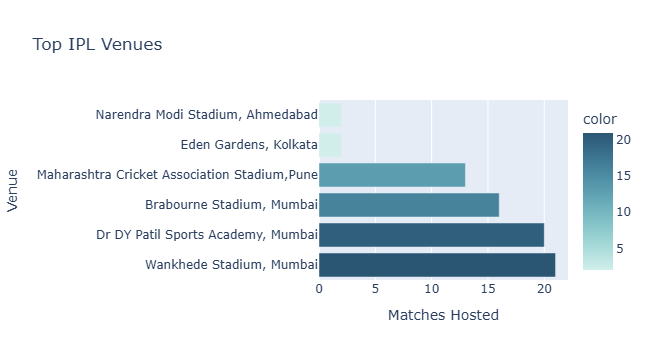

In [20]:
top_venues = df['venue'].value_counts().head(15)
fig = px.bar(x=top_venues.values,y=top_venues.index,orientation='h',title='Top IPL Venues',
            color=top_venues.values, color_continuous_scale='Teal')

fig.update_layout(
    xaxis_title='Matches Hosted',
    yaxis_title='Venue'
)
fig.show()

# INSIGHTS

# Advanced Analytical Questions to Explore
To turn this data exploration into a strategic cricket analysis, we will answer specific questions regarding stadium behaviors, toss impact, and player dominance:

# Team Dominance (Biggest Win by what Margin (Runs))

In [83]:
#Who won the highest margin by runs?
count = df[df['won_by'] == 'Runs'].sort_values(by = 'margin', ascending=False).head(1)
print(f" team name : \n{count['match_winner']}")
print(f" and with margin : \n{count['margin']}")

 team name : 
54    Chennai
Name: match_winner, dtype: object
 and with margin : 
54    91
Name: margin, dtype: int64


In [66]:
run_wins = df[df['won_by'] == 'Runs']

# max victory margin for each team then avg
max_margins = run_wins.groupby('match_winner')['margin'].max().sort_values(ascending=False)
avg_margins = run_wins.groupby('match_winner')['margin'].mean()
avg_margins

match_winner
Banglore     25.600000
Chennai      42.333333
Delhi        27.333333
Gujarat      30.250000
Hyderabad     3.000000
Kolkata      53.000000
Lucknow      24.142857
Mumbai        5.000000
Punjab       32.750000
Rajasthan    23.142857
Name: margin, dtype: float64

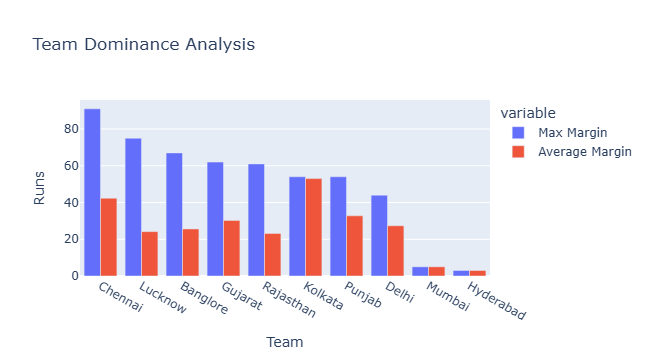

In [67]:
dominance = pd.DataFrame({
    'Team': max_margins.index,'Max Margin': max_margins.values,
    'Average Margin': avg_margins.loc[max_margins.index].values
})

fig = px.bar(dominance,x='Team',y=['Max Margin', 'Average Margin'],barmode='group',title='Team Dominance Analysis')
fig.update_layout(xaxis_title='Team',yaxis_title='Runs')
fig.show()

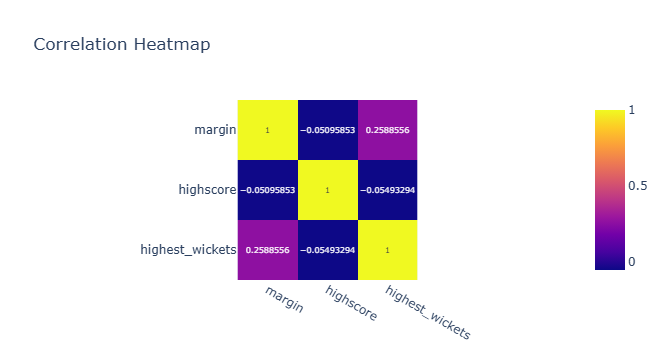

In [68]:
numeric_cols = ['margin', 'highscore', 'highest_wickets']
corr = df[numeric_cols].corr()
fig = px.imshow(corr,text_auto=True,title='Correlation Heatmap')
fig.show()

In [88]:
#highest individual score?
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


# Ultimate "Clutch" Players of the Season

In [9]:
#how many times each player won the Player of the Match award
motm_counts = df['player_of_the_match'].value_counts().head(10)
motm_counts

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

Text(0, 0.5, 'Player Name')

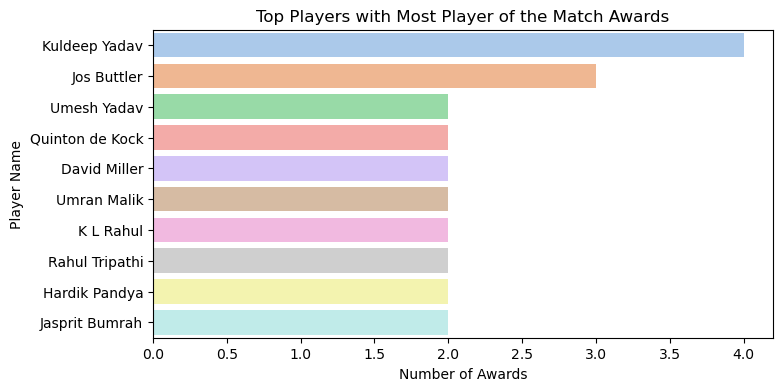

In [10]:
plt.figure(figsize=(8, 4))
plt.title('Top Players with Most Player of the Match Awards')
sns.barplot(x=motm_counts.values, y=motm_counts.index, palette='pastel')
plt.xlabel('Number of Awards')
plt.ylabel('Player Name')

In [116]:
#highest wickets by which player?
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


# Toss Advantage

In [6]:
df = pd.read_csv("IPL.csv")
toss_match_matches = df[df['toss_winner'] == df['match_winner']]
toss_match_matches.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59


In [12]:
#TOSS WINNER VS MATCH WINNER
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
per = (count*100)/df.shape[0]
per.round(3) 
#48 percentage chances when match is won by same team who won toss

np.float64(48.649)

In [35]:
# how many times the toss winner won the match
won_count = len(toss_match_matches)
# how many times they lost
lost_count = len(df) - won_count

# lists for the labels and numbers
labels = ['Won Match', 'Lost Match']
sizes = [won_count, lost_count]
colors = ['lightblue', 'lightcoral']

print(f"won count = {won_count} and lost_count = {lost_count}")

won count = 36 and lost_count = 38


Text(0.5, 1.0, 'Does Winning the Toss Give an Advantage?')

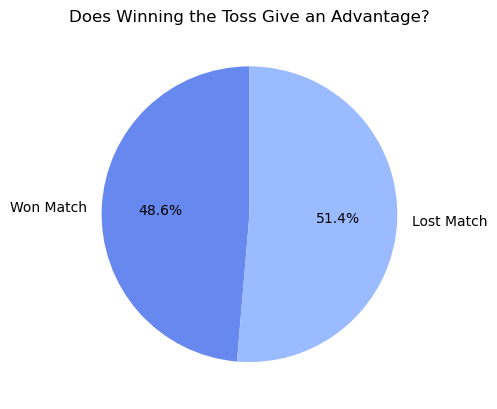

In [42]:
colors = sns.color_palette("coolwarm")
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Does Winning the Toss Give an Advantage?')

# Chasing vs Defending Grounds

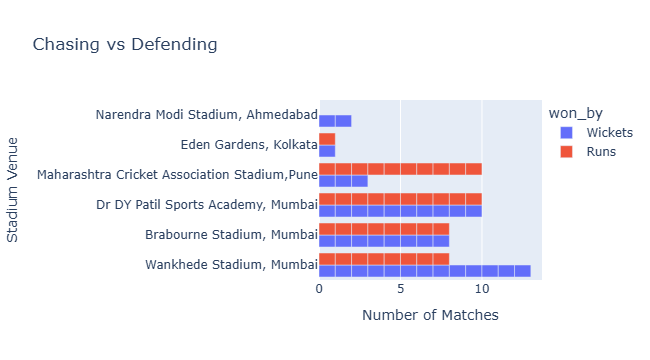

In [15]:
# how many matches were won by runs (defending) vs wickets (chasing) at each stadium
fig = px.bar(df, y='venue', color='won_by', barmode='group', 
    color_continuous_scale='Teal', 
    title='Chasing vs Defending'
)
fig.update_layout(
    xaxis_title='Number of Matches',
    yaxis_title='Stadium Venue'
)
fig.show()

# Average "Safe" Score to Defend per Venue

In [18]:

#matches where the team batting first won (Defended their score)
defending_wins = df[df['won_by'] == 'Runs']
print(f" original rows and cols are = {df.shape}\n now remaining rows and cols after calculation is = {defending_wins.shape} \n meaning that there were in total: {defending_wins.shape[0]} matches where the team batting first won")

 original rows and cols are = (74, 20)
 now remaining rows and cols after calculation is = (37, 20) 
 meaning that there were in total: 37 matches where the team batting first won


In [19]:
#Group by the stadium, the average first innings score and sort
avg_defended_score = defending_wins.groupby('venue')['first_ings_score'].mean()
avg_defended_score = avg_defended_score.sort_values()

avg_defended_score

venue
Maharashtra Cricket Association Stadium,Pune    174.800
Dr DY Patil Sports Academy, Mumbai              184.900
Wankhede Stadium, Mumbai                        188.875
Brabourne Stadium, Mumbai                       197.750
Eden Gardens, Kolkata                           207.000
Name: first_ings_score, dtype: float64

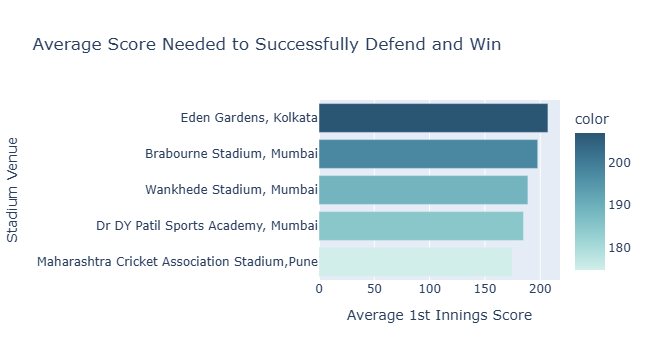

In [21]:
fig = px.bar(
    x=avg_defended_score.values, y=avg_defended_score.index,
    orientation='h', color=avg_defended_score.values,  
    color_continuous_scale="Teal" , title='Average Score Needed to Successfully Defend and Win'
)

fig.update_layout(
    xaxis_title='Average 1st Innings Score',
    yaxis_title='Stadium Venue',
    showlegend=False 
)

fig.show()

# Does a Massive Individual Score Guarantee Victory?

In [6]:
df = pd.read_csv("IPL.csv")
match_results_for_top_scorer = []
for index, row in df.iterrows():
    # If the Top Scorer was also named the Player of the Match, their team won
    # MOTM is man of the match
    if row['player_of_the_match'] == row['top_scorer']:
        match_results_for_top_scorer.append('Won Match (MOTM)')
    else:
        match_results_for_top_scorer.append('Did Not Get MOTM')

#Add as a column in our DataFrame
df['top_scorer_outcome'] = match_results_for_top_scorer
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,top_scorer_outcome
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Did Not Get MOTM
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,Did Not Get MOTM
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,Did Not Get MOTM


In [7]:
# Count the total values
outcome_counts = df['top_scorer_outcome'].value_counts()
outcome_counts

top_scorer_outcome
Did Not Get MOTM    45
Won Match (MOTM)    29
Name: count, dtype: int64

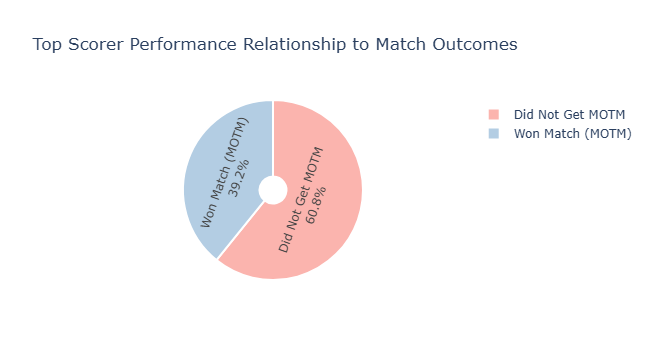

In [8]:
fig = px.pie(
    names=outcome_counts.index,
    values=outcome_counts.values,
    title='Top Scorer Performance Relationship to Match Outcomes',
    color_discrete_sequence=px.colors.qualitative.Pastel1,
    hole=0.15
)

fig.update_traces(
    textinfo='percent+label',
    textfont_size=12,
    marker=dict(line=dict(color='#FFFFFF', width=2))
)

# Group Stages vs Playoff Matches Scoring Trend
(using first innings score) whether there is a difference in the runs scored during the Group Stages of the tournament compared to the high-pressure Playoff Matches (like Semifinals and Finals).

column called 'stage' marks whether a match is regular (Group) or sudden-death knockout stage (Playoff).

Text(0, 0.5, '1st Innings Scores')

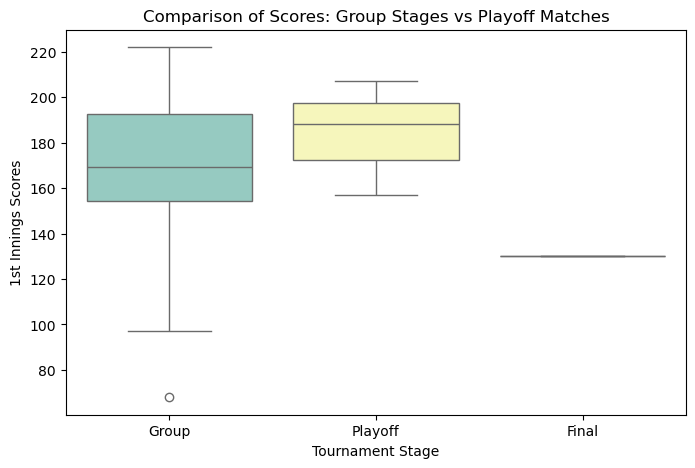

In [97]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stage', y='first_ings_score', palette='Set3')
plt.title('Comparison of Scores: Group Stages vs Playoff Matches')
plt.xlabel('Tournament Stage')
plt.ylabel('1st Innings Scores')

# Do Pitches Get Tired? (Scoring Over Time)

In [99]:
#date strings into actual datetime formats 
df['datetime_clean'] = pd.to_datetime(df['date'].str.replace(' ', ''), format='%B%d,%Y')
df['datetime_clean'].head(3)

0   2022-03-26
1   2022-03-27
2   2022-03-27
Name: datetime_clean, dtype: datetime64[ns]

In [101]:
#Sort from the first match to the last match
df_chronological = df.sort_values(by='datetime_clean')
df_chronological.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets,top_scorer_outcome,datetime_clean
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,Did Not Get MOTM,2022-03-26
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,Did Not Get MOTM,2022-03-27
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,Did Not Get MOTM,2022-03-27


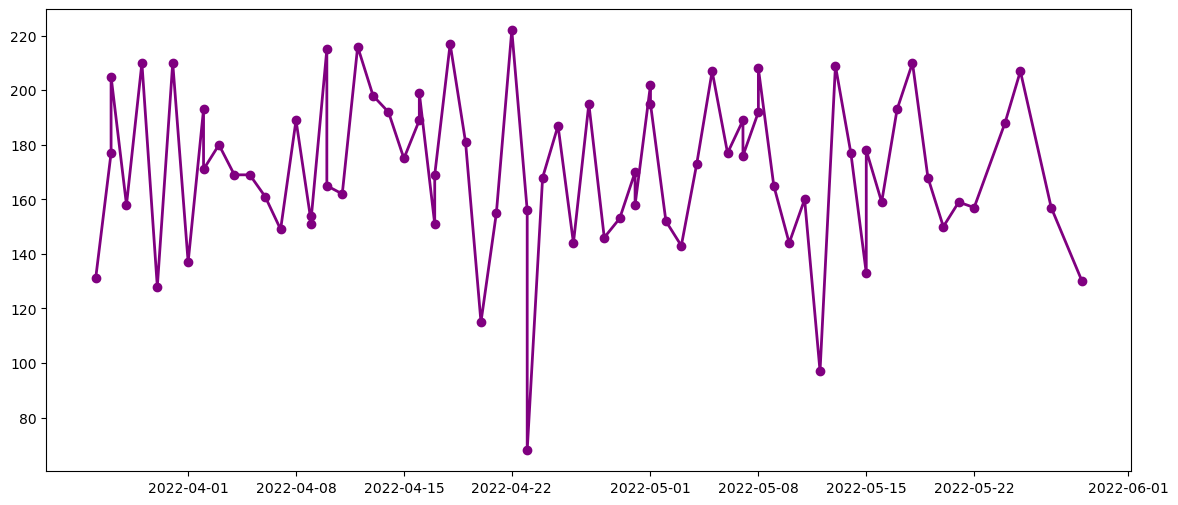

In [102]:
#line plot tracking 1st innings scores across match dates
plt.figure(figsize=(14, 6))
plt.plot(df_chronological['datetime_clean'], df_chronological['first_ings_score'], 
         marker='o', color='purple', linestyle='-', linewidth=2, label='Match Score')

A rolling average (also known as a moving average) is a statistical technique used to analyze data points by creating a series of averages of different subsets of the full data set.
Instead of calculating a single average for the entire tournament, or forcing a straight line through it, you calculate the average within a moving "window" of consecutive matches.
By constantly dropping the oldest match and adding the newest one, the rolling average line dynamically adapts to changes in the data.

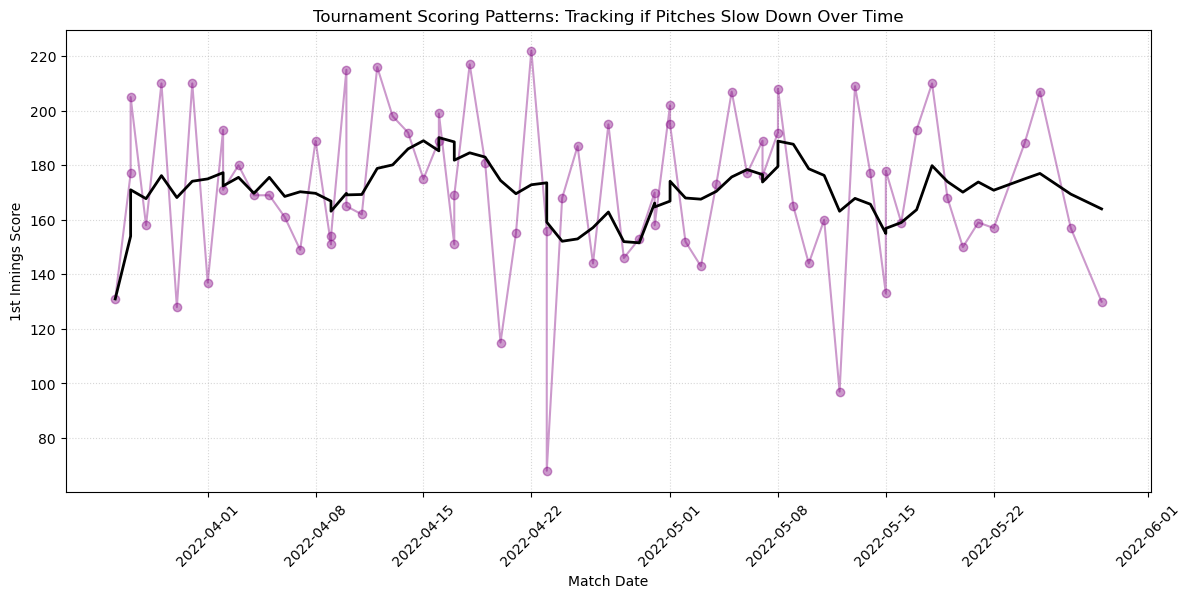

In [112]:
# Add a simple trend across the tournament using basic linear math
x_numbers = np.arange(len(df_chronological))
slope, intercept = np.polyfit(x_numbers, df_chronological['first_ings_score'], 1)
trend_line_values = (slope * x_numbers) + intercept

df_chronological['rolling_avg_score'] = df_chronological['first_ings_score'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_chronological['datetime_clean'], df_chronological['first_ings_score'], marker='o', alpha=0.4, color='purple', label='Match Score')
plt.plot(df_chronological['datetime_clean'], df_chronological['rolling_avg_score'], color='black', linewidth=2, label='7-Match Rolling Trend')

plt.title('Tournament Scoring Patterns: Tracking if Pitches Slow Down Over Time')
plt.xlabel('Match Date')
plt.ylabel('1st Innings Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.5)